In [54]:
using Pkg
Pkg.add(["PyPlot"])

   Resolving package versions...
    Updating `D:\notes\econ_hbc\code\quan_macro\Project.toml`
  [d330b81b] + PyPlot v2.11.6
    Updating `D:\notes\econ_hbc\code\quan_macro\Manifest.toml`
  [8f4d0f93] + Conda v1.10.3
  [438e738f] + PyCall v1.96.4
  [d330b81b] + PyPlot v2.11.6
  [81def892] + VersionParsing v1.3.0
Precompiling packages...
   1030.6 ms  ✓ VersionParsing
    825.7 ms  ✓ Conda
              ✗ Dynare
  11680.0 ms  ✓ PyCall
   3199.2 ms  ✓ PyPlot
  4 dependencies successfully precompiled in 18 seconds. 443 already precompiled.

The following 1 direct dependency failed to precompile:

Dynare 

Failed to precompile Dynare [5203de40-99df-439e-afbc-014de65cb9ef] to "C:\\Users\\ZhuanZ1\\.julia\\compiled\\v1.12\\Dynare\\jl_8900.tmp".
ERROR: LoadError: UndefVarError: `ShiftedExp` not defined in `TransformVariables`
Suggestion: check for spelling errors or missing imports.
Stacktrace:
  [1] getproperty(x::Module, f::Symbol)
    @ Base .\Base_compiler.jl:47
  [2] top-level scope
    @

In [1]:
using Pkg
#Pkg.activate("D:/notes/econ_hbc/code/quan_macro")
Pkg.develop(path="D:/Library_Julia/CompEcon.jl")   
#Pkg.instantiate()       
using Optim, QuantEcon, Random, LinearAlgebra, Plots; pyplot()
using Printf, Statistics, Parameters, QuantEcon, LaTeXStrings
const Out_Dir = joinpath(@__DIR__,"OUTPUT")
using CompEcon, BasisMatrices, LaTeXStrings

   Resolving package versions...
     Project No packages added to or removed from `D:\notes\econ_hbc\code\quan_macro\Project.toml`
    Manifest No packages added to or removed from `D:\notes\econ_hbc\code\quan_macro\Manifest.toml`


In [58]:
using Plots; pyplot()

Plots.PyPlotBackend()

In [2]:
function setup(;
    β = 0.8,
    ρ = 0.9,
    σ = 0.2,
    ϕ_mean = 1.0,
    α = 2/3,
    c_e = 40.0,
    c_f = 20.0,
    D_bar = 100.0,
    μ_g = 0.0,
    σ_g = 0.2,
    N_ϕ = 101,
    w = 1.0)

    function Tauchen_Hussey(μ::Float64, σ :: Float64, ρ :: Float64, N::Int64 )

        pdf_normal(z) = exp.(-z.^2.0 ./2.0) ./ sqrt(2.0*pi)

        σ_bar = σ/sqrt(1.0 -ρ^2.0)
        θ = 1/2+ρ/4 # Floden's advice
        σ_hat = θ*σ+(1-θ)*σ_bar
        nodes, weights = QuantEcon.qnwnorm(N,μ,σ_hat^2)
        ω = pdf_normal((nodes .- μ)./σ_hat) ./ σ_hat
        p = fill(0.0, N, N)

        for i in 1:N , j in 1:N
            p[i,j] = pdf_normal((nodes[j]-(1-ρ)*μ-ρ*nodes[i])/σ)/σ
        end

        P = fill(0.0,N,N)
        for i in 1:N , j in 1:N
            P[i,j] = (p[i,j]*weights[j]/ω[j])/(sum(p[i,k]*weights[k]/ω[k] for k = 1:N))
        end

        return nodes, P
    end



    # === 离散化冲击
    #ϕ_mean = (1-ρ)*ϕ_mean
    #mc = QuantEcon.tauchen(N_ϕ, ρ, σ,  ϕ_mean, 4.0)
    #F = mc.p
    grid_Φ, F = Tauchen_Hussey(ϕ_mean, σ, ρ, N_ϕ)
    grid_Φ = exp.(grid_Φ)

    # === 构造进入者的初始抽样分布
    inv_Φ = F^1000
    G = inv_Φ[1,:]

    return (β = β, F = F, grid_Φ = grid_Φ, α = α, c_e = c_e, c_f = c_f,
            D_bar = D_bar, N_ϕ = N_ϕ, w = w, G = G )
end

setup (generic function with 1 method)

In [10]:
params = setup()

(β = 0.8, F = [0.018254834244862253 0.13458044946659378 … 0.0 0.0; 0.0008238394187713784 0.0186076955648418 … 0.0 0.0; … ; 0.0 0.0 … 0.0186076955648416 0.0008238394187713656; 0.0 0.0 … 0.13458044946659342 0.018254834244862156], grid_Φ = [0.015468799151658238, 0.01933461070450781, 0.023242116443464828, 0.027378651851713804, 0.03183101853854843, 0.036659867781623716, 0.041917208651684947, 0.0476526095464831, 0.05391599771121407, 0.06075918114055946  …  121.61217383487951, 137.0475631093401, 155.06089108767355, 176.27738908691938, 201.55708533773057, 232.13382537483852, 269.8838547255979, 317.91666292112956, 382.16730669461646, 477.6748360675788], α = 0.6666666666666666, c_e = 40.0, c_f = 20.0, D_bar = 100.0, N_ϕ = 101, w = 1.0, G = [6.20942817287187e-29, 1.0143574286380816e-26, 6.133315177385739e-25, 2.1241536021298883e-23, 5.029243296392165e-22, 8.946227633710036e-21, 1.2670817056095107e-19, 1.485689655832307e-18, 1.4828421159155585e-17, 1.2862382509646024e-16  …  1.2862382509646084e-16

In [3]:
function solve_incubment_problem(par,p)
    @unpack grid_Φ, β, F, c_f, N_ϕ, w, α = par 

    n = ((p*grid_Φ*α)./(w)).^(1/(1-α))
    π = p*grid_Φ.*n.^α .- w*n .-w*c_f

    tol = 10.0^(-8)
    maxit = 500
    V = π
    crit = 0.0
    print_if = false
    function VFI(V)
        V_guess = fill(0.0, N_ϕ)
        for iter in 1:maxit
            V_guess .= V
            V = π + β*max.(0,F*V_guess)
            crit = maximum(abs.(V - V_guess))
            if crit<tol && print_if 
                @printf("Iteration is over! Iter is %1.0f, Tol is %0.4f", iter, crit)
                break
            end
        end
        χ = fill(0.0, N_ϕ)
        χ[F*V .<0.0] .= 1.0
        return V, χ
    end

    V, χ = VFI(V)
    return (V = V, χ = χ, n = n, π = π)
end

solve_incubment_problem (generic function with 1 method)

In [14]:
sol = solve_incubment_problem(params,2.0)

(V = [-19.999999705177302, -19.999999424298437, -19.99999899995825, -19.999998365340545, -19.999997431126495, -19.999996075685583, -19.99999413364722, -19.99999138111317, -19.999987516279067, -19.99998213401975  …  210281.5074063883, 296057.28061602835, 421968.8677109523, 610198.7646284614, 897942.5974081904, 1.3504070209525048e6, 2.0889794518121681e6, 3.3601044437679294e6, 5.739014021826575e6, 1.0995018332594754e7], χ = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], n = [5.896453939988093e-7, 1.1514031283226497e-6, 2.000083498367984e-6, 3.269318910680348e-6, 5.137747011158939e-6, 7.84862883434858e-6, 1.1732705561670592e-5, 1.7237773659425492e-5, 2.4967441863574575e-5, 3.573196050172372e-5  …  286518.232609996, 410048.3432217479, 593919.979048226, 872591.4169439272, 1.304413597167353e6, 1.992674638982398e6, 3.131495718327929e6, 5.1187153831316875e6, 8.891636576981016e6, 1.7362737460244983e7], π = [-19.999999705177302, -19.999999

In [4]:
function solve_price(par)
    sol_last = Ref{Any}(nothing)
    function obj_entry(p_guess)
        @unpack β, c_e, G, w =par
        sol = solve_incubment_problem(par,p_guess)
        sol_last[] = sol
        V = sol.V 
        err_entry = β*sum(G.*V) .-c_e*w
        return err_entry
    end

    p = QuantEcon.brent(obj_entry,0.001,5.0)
    
    return (V = sol_last[].V, χ = sol_last[].χ, n = sol_last[].n, π = sol_last[].π, p = p)
end



solve_price (generic function with 1 method)

In [16]:
test1 = solve_price(params)

(V = [-19.99999820037218, -19.999996485858915, -19.999993895643133, -19.999990021871906, -19.999984319334025, -19.99997604558441, -19.999964191184095, -19.999947389435427, -19.99992379809375, -19.999890944233726  …  1.284078342766e6, 1.8076631362334955e6, 2.5762409913500487e6, 3.725216131586287e6, 5.481634458332334e6, 8.243524051403944e6, 1.2751846092658706e7, 2.0510923291159634e7, 3.503203063167666e7, 6.711521780326669e7], χ = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], n = [3.5992556450260716e-6, 7.0282821700873685e-6, 1.2208713737597674e-5, 1.9956256191293992e-5, 3.136133194770107e-5, 4.7908831181000555e-5, 7.161763180729084e-5, 0.00010522112914443316, 0.0001524038125014379, 0.000218111532545843  …  1.7489365245961759e6, 2.5029769232411645e6, 3.625348148293022e6, 5.326387037364137e6, 7.962273683194139e6, 1.2163489304000508e7, 1.9114969363416288e7, 3.12451609484729e7, 5.4275456857522465e7, 1.0598392093438208e8], π = [-19.99

In [5]:
function solve_mass(par,sol)
    @unpack F, G, N_ϕ, α, grid_Φ, D_bar =par 
    @unpack n, χ, p = sol 

    F_hat = F.*(1.0 .- χ)
    μ = (I - (F_hat)')\G
    
    y = grid_Φ.*n.^α
    Y = sum(μ.*y)
    D = D_bar/p

    M = D/Y 
    μ = M*μ

    return (M = M, μ = μ)
end

solve_mass (generic function with 1 method)

In [18]:
dist = solve_mass(params,test1)

(M = 0.0880648990028718, μ = [5.4683266490955704e-30, 8.932928450582686e-28, 5.401297816492697e-26, 1.8706337243815948e-24, 4.428998029576563e-23, 7.878486330193917e-22, 1.1158542243289039e-20, 1.308371094904872e-19, 1.305863411753118e-18, 1.1327244166483117e-17  …  3.568818039232134e-16, 4.152162898409927e-17, 4.198157245145294e-18, 3.6130971175077334e-19, 2.5744003564850145e-20, 1.46065652105073e-21, 6.227801697845273e-23, 1.816002332774464e-24, 3.0352688841392034e-26, 1.8807595752565333e-28])

In [6]:
function statistic_model(par,sol,dist)
    @unpack F, G, D_bar, α, grid_Φ, N_ϕ = par 
    @unpack π, n, χ, p = sol 
    @unpack M, μ = dist

    # === 生产率分布
    pdf_product = μ./sum(μ)
    cdf_product = cumsum(pdf_product)

    # === 雇佣分布
    emp_dist = μ.*n 
    pdf_emp = emp_dist./sum(emp_dist)
    cdf_emp = cumsum(pdf_emp)

    # === 退出阈值
    cutoff = findfirst(χ .== 0)
    if cutoff !== nothing
        ϕ_cutoff = grid_Φ[cutoff]
    else
        ϕ_cutoff = NaN
    end

    # === 统计量
    avg_firm_size = sum(emp_dist)/sum(μ)
    exit_rate = M/sum(μ)
    Y_agg = sum((grid_Φ.*n.^α).*μ)
    N_agg = sum(emp_dist)
    Π_agg = sum(π.*μ)

    return (pdf_product = pdf_product, cdf_product = cdf_product, 
            pdf_emp = pdf_emp, cdf_emp = cdf_emp, ϕ_cutoff = ϕ_cutoff,
            avg_firm_size = avg_firm_size, exit_rate = exit_rate,
            Y_agg = Y_agg, N_agg = N_agg, Π_agg = Π_agg)
end

statistic_model (generic function with 1 method)

In [7]:
function solve_model(par)
    sol = solve_price(par) 
    dist = solve_mass(par,sol)

    if dist.M < 0.0
        @printf("Warning: No entry")
    end
    stats = statistic_model(par,sol,dist)
    return (sol = sol, dist = dist, stats = stats)
end

solve_model (generic function with 1 method)

In [8]:
begin
    solution_info = solve_model(setup(;α = 2/3, c_e = 40, c_f = 20,
    ρ = 0.9, σ = 0.2, D_bar = 100, ϕ_mean = 1.39))
    function print_info(solution_info)
        @unpack sol, stats = solution_info

       # with_terminal()do 
            @printf("Price: %1.4f\n", sol.p)
            @printf("Avg. Firm Size: %1.4f\n", stats.avg_firm_size)
            @printf("Exit/Entry Rate: %0.4f\n", stats.exit_rate)
            @printf("Productivity Cutoff: %1.4f\n", stats.ϕ_cutoff)
            @printf("Agg. Output: %2.4f\n", stats.Y_agg)
            @printf("Agg. Employment: %2.4f\n", stats.N_agg)
            @printf("Agg. Profit: %2.4f\n", stats.Π_agg)
       # end
    end
    print_info(solution_info)
end

Price: 1.0062
Avg. Firm Size: 105.1246
Exit/Entry Rate: 0.1389
Productivity Cutoff: 4.0149
Agg. Output: 99.3885
Agg. Employment: 66.6667
Agg. Profit: 20.6500


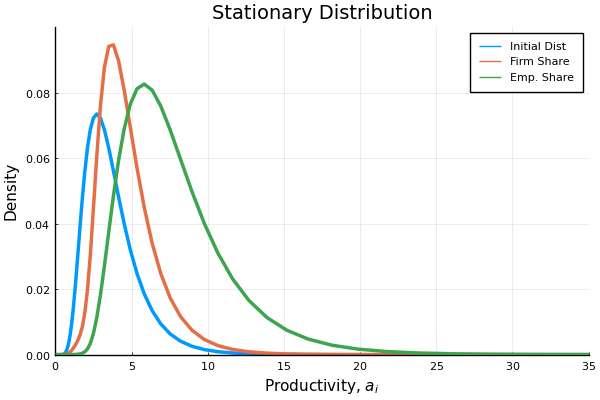

In [11]:
begin
    @unpack sol, stats = solution_info
    Plots.pyplot()
    plot(params.grid_Φ, [params.G, stats.pdf_product, stats.pdf_emp],
     label = ["Initial Dist" "Firm Share" "Emp. Share"], 
     lw = 2.5)

    title!("Stationary Distribution")
    xlims!(0,35)
    ylims!(0,0.1)
    xlabel!(L"\text{Productivity, } a_i")
	ylabel!("Density")
end

In [34]:
begin
    solution_info = solve_model(setup(;α = 2/3, c_e = 60, c_f = 20,
    ρ = 0.9, σ = 0.2, D_bar = 100))
        print_info(solution_info)
end

Price: 1.5974
Avg. Firm Size: 120.6457
Exit/Entry Rate: 0.1060
Productivity Cutoff: 2.4979
Agg. Output: 62.6017
Agg. Employment: 66.6667
Agg. Profit: 22.2817


In [35]:
begin
    solution_info = solve_model(setup(;α = 2/3, c_f = 30,
    ρ = 0.9, σ = 0.2, D_bar = 100))
        print_info(solution_info)
end

Price: 1.5974
Avg. Firm Size: 140.8897
Exit/Entry Rate: 0.1812
Productivity Cutoff: 2.9582
Agg. Output: 62.6030
Agg. Employment: 66.6667
Agg. Profit: 19.1378
